# Homework #1
## Introduction to supervised learning

This colaboratory contains Homework #1 of the Machine Learning course, which is due **September 20, Sunday, 23:59 (Estonian time)**. To complete the homework, export it with **File -> Download -> Download .ipynb** and submit it on the course webpage.

**NB! Links to your colaboratory will not be accepted as a solution!**

## Submission's rules:

1. Please, submit only .ipynb that you extract from the Colaboratory. Submit your .ipynb to [course webpage](https://courses.cs.ut.ee/2026/ml/fall/Main/Homeworks).
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in the same .ipynb file.
7. You may use AI assistants, but what you submit is yours and so is the responsibility for it. The point of the course is not the grade — you are here to train your own thinking, not the generative AI's. 🙂

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:
1. Pooh


## List of Homework's exercises:
1. [EX1](#scrollTo=tz9XASPxeqDC) - 3 points
2. [EX2](#scrollTo=BGVGqZGpxmzQ&uniqifier=1#) - 2 points
4. [EX3](#scrollTo=7p4GMeGK-QGL&uniqifier=1) - 1 points
5. [EX4](#scrollTo=nqV2c5sDc_f2&uniqifier=1) - 4 points
6. [Bonus 1](#scrollTo=_2T9ydozzcb-&uniqifier=1) - 2 points
7. [Bonus 2](#scrollTo=chg13old0&uniqifier=1) - up to 5 points

### Homework setup:
Here we will load necessary libraries (NumPy and Pandas) and MNIST dataset

In [6]:
import numpy as np # for matrix stuff
import pandas as pd # to work with datasets
import matplotlib.pyplot as plt # subjectively ugly plotting here

# Getting MNIST one more time
from tensorflow.keras.datasets import mnist
(images, labels),(_, _) = mnist.load_data()
images = images / 255 # normalising images

print(f"images are of shape: {images.shape} and labels: {labels.shape}")

# Subsample the images
train_images = images[:2000]
train_labels = labels[:2000]

test_images = images[2000:3000]
test_labels = labels[2000:3000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
images are of shape: (60000, 28, 28) and labels: (60000,)


## Homework exercise 1 (3 points): KNN
<font color='red'>One very popular variation of Nearest Neighbour is K-nearest neighbour. In this algorithm a label for a new instance is chosen by majority vote by **`k`** of its nearest neighbors.

<font color='red'>The actual algorithm is not very different from vanilla nearest neighbour:

1. <font color='red'> Calculate distances between the image you want to classify and all other images
2. <font color='red'> Find the **`k`** closest images (you may consider using `np.argsort` function)
3. <font color='red'> Report the most popular label from these **`k`**. (maybe `np.bincount` can help)

<font color='red'>**(Homework exercise 1- a)** Implement the aformentioned algorithm in the cell below (2.0 points)</font>

In [7]:
def dist(img1, img2):
  ##### YOUR CODE STARTS #####
  return np.sqrt(np.sum((img1 - img2)**2))
  ##### YOUR CODE ENDS #####

def classify_knn(image, k, train_images, train_labels):
  ##### YOUR CODE STARTS #####
  all_distances = np.array([dist(image, t_img) for t_img in train_images])
  knn = np.argsort(all_distances)[:k]
  counts = np.bincount(train_labels[knn])
  prediction = np.argmax(counts)
  ##### YOUR CODE ENDS #####
  return prediction

Test the function on two first images from `test_images`:

In [8]:
##### YOUR CODE STARTS #####
print(f"Predicted class for the first image is {classify_knn(test_images[0], 5, train_images, train_labels)} and the true label is {test_labels[0]}")
print(f"Predicted class for the second image is {classify_knn(test_images[1], 5, train_images, train_labels)} and the true label is {test_labels[1]}")
##### YOUR CODE ENDS #####

Predicted class for the first image is 6 and the true label is 5
Predicted class for the second image is 8 and the true label is 8


<font color='red'>**(Homework exercise 1- b)** Create a new function `classify_knn_print` from `classify_knn` that you have just implemented in **1- a**  by adding a print statement that outputs labels of K nearest neighbours. Report 10 nearest neighbours for the first two images from the `test_images`. Why do you think these digits were among the closest neighbours? (0.5 points) </font>

In [9]:
def classify_knn_print(image, k, train_images, train_labels):
  ##### YOUR CODE STARTS #####
  all_distances = np.array([dist(image, t_img) for t_img in train_images])
  knn = np.argsort(all_distances)[:k]
  counts = np.bincount(train_labels[knn])
  knn_labels = train_labels[knn]
  print(f"Labels of {k} nearest neighbours: {knn_labels}")
  prediction = np.argmax(counts)
  ##### YOUR CODE ENDS #####
  return prediction

In [10]:
##### YOUR CODE STARTS #####
print(f"Predicted class for the first image is {classify_knn_print(test_images[0], 10, train_images, train_labels)} and the true label is {test_labels[0]}")
print(f"Predicted class for the second image is {classify_knn_print(test_images[1], 10, train_images, train_labels)} and the true label is {test_labels[1]}")
##### YOUR CODE ENDS #####

Labels of 10 nearest neighbours: [6 6 5 9 6 6 9 5 9 6]
Predicted class for the first image is 6 and the true label is 5
Labels of 10 nearest neighbours: [8 8 8 8 8 8 8 8 8 8]
Predicted class for the second image is 8 and the true label is 8


Answer to (b): because the digits 5 and 6 look somewhat similar in handwriting

```
# This is formatted as code
```



<font color='red'>**(Homework exercise 1- c)** Classify all test images using `classify_knn` (**please, do not use print version**) and store the predicted labels into a separate variable `test_predicted`, choose `k` = 5. Compute accuracy of your KNN model. (0.5 points) </font>

In [11]:
##### YOUR CODE STARTS #####
# Проходимся по всем картинкам из тестовой выборки и сохраняем предсказания в список
test_predicted = [classify_knn(img, 5, train_images, train_labels) for img in test_images]
n_correct = np.sum(np.array(test_predicted) == test_labels)
knn_accuracy = n_correct / len(test_labels)
##### YOUR CODE ENDS ##### (please do not delete this line)
print(f"Final accuracy of our nearest neighbor classifier is {knn_accuracy}. Not bad!")

Final accuracy of our nearest neighbor classifier is 0.912. Not bad!


## Homework exercise 2 (2 points): exploring misclassified examples
<font color='red'>**(Homework exercise 2- a)** Modify the visualisation code that we used during the practice session to visualise a grid of example images from different classes. Now, instead of random examples from each class, visualise misclassified examples from each class. For example, in the first column visualise images that had true label `0` but were classified as something else, in the second column, show examples of images that had label `1` but were misclassified into another class and so on. Add a title to each small image, in the following format `true_label, predicted_label` e.g. "0, 6" - image of class 0 was classified as 6. (1.5 points)

**NB! you need a variable `test_predicted` to exist from the previous exercise to complete this exericse.** </font>

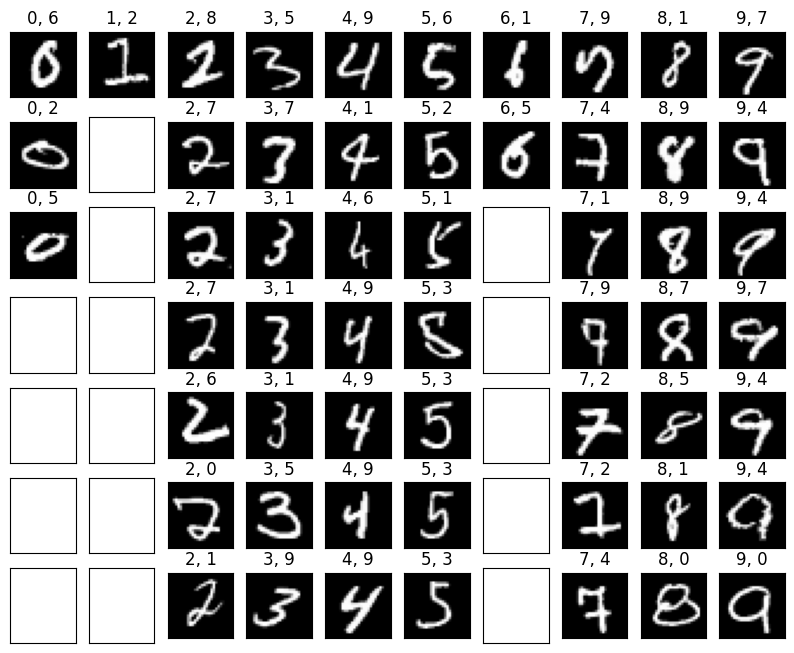

In [12]:
num_classes = 10
samples_per_class = 7 # Number of images from each class we want to see
fig, axs = plt.subplots(samples_per_class, num_classes, figsize=(10.0, 8.0))
for i in range(num_classes):
    ##### YOUR CODE STARTS #####
    misclassified_idx = np.where((test_labels == i) & (np.array(test_predicted) != i))[0]

    for j in range(min(samples_per_class, len(misclassified_idx))):
        idx = misclassified_idx[j]
        wrong_pred = test_predicted[idx]

        axs[j, i].imshow(test_images[idx], cmap='gray')
        axs[j, i].set_title(f"{i}, {wrong_pred}")
    ##### YOUR CODE ENDS #####
plt.setp(axs,xticks=[],yticks=[]) # set all axes off
plt.show()

<font color='red'>**(Homework exercise 2- b)** Take a careful look at the resulting figure. Are all classes equally missclassified? Why? Are there any classes that KNN confuses more often, why? (0.5 points) </font>

Answer to (b):not all classes are misclassified equally: digits with distinct shapes (like 1 or 0) have almost no errors, while digits sharing pixel overlaps are frequently confused by the euclidean distance, such as a 1 with a horizontal baseline being misclassified as a 2

## Preparation for homework exercises 3 and 4
Next we will work with real-world dataset collected from taxis operating in New York City that we have already discussed during our practice sessions. This dataset provides comprehensive trip records of taxi rides, including information such as pickup and drop-off times, passenger count, trip distance, and fare details.

In [13]:
# The data sits in a public Google Drive folder. gdown ships with Colab and handles
# Drive's large-file confirmation page for us - no sign-in, no PyDrive.
!gdown 1XKhfq4WFHlTrvag48cD3VDJGfykYUJ-s -O nyc_data_2.zip

Downloading...
From (original): https://drive.google.com/uc?id=1XKhfq4WFHlTrvag48cD3VDJGfykYUJ-s
From (redirected): https://drive.google.com/uc?id=1XKhfq4WFHlTrvag48cD3VDJGfykYUJ-s&confirm=t&uuid=6ef553a3-b8ad-4c87-82e2-8741bd6e6f2c
To: /content/nyc_data_2.zip
100% 49.2M/49.2M [00:00<00:00, 215MB/s]


In [14]:
# -o overwrites without asking, so re-running this cell does not hang on a prompt
!unzip -o -q nyc_data_2.zip

# check that train_2M.csv, test.csv, model.pickle and sample_submission.csv exist
!ls -lh

total 193M
-rw-r--r-- 1 root root  794 Feb  7  2022 model.pickle
-rw-r--r-- 1 root root  47M Feb  7  2022 nyc_data_2.zip
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data
-rw-r--r-- 1 root root 336K Apr  2  2019 sample_submission.csv
-rw-r--r-- 1 root root 960K Apr  2  2019 test.csv
-rw-r--r-- 1 root root 145M Apr 23  2019 train_2M.csv


* `train_2M.csv` contains 2 million observations from NYC dataset (6 independent variables and fare_amount that we need to predict).
* `test.csv` contains new observations, for which we have to estimate `fare_amount` based on train data.
* `sample_submission.csv` - a sample submission file in the correct format (columns `key` and `fare_amount`). Every row in this file matches every row in `test.csv`.
* `model.pickle` - file that contains trained model saved as a pickle (we are going to deal with it later)

## Homework exercise 3 (1 point): read and explore `model.pickle`

<font color='red'> **(Homework exercise 3- a)** In this exercise we will use module `pickle` that let's you store your machine learning models as files. Later you can share these models (aka pickles) with your colleagues or your future self.

<font color='red'> In this exercise, use `pickle` module to read in `model.pickle` file that you have downloaded from `nyc_data_2.zip` using `pickle.load()` function. For details consult the documentation page: https://docs.python.org/3/library/pickle.html. (0.5 points)

In [15]:
import pickle
import os

##### YOUR CODE STARTS #####
filename = 'model.pickle'
with open(filename, 'rb') as file:
    model = pickle.load(file)
##### YOUR CODE ENDS #####

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.0.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [16]:
dir(model)
print(type(model))
print(model.coef_)
print(model.feature_names_in_)

<class 'sklearn.linear_model._base.LinearRegression'>
[[1.46111427e+02 8.92591108e+01 5.23209145e-02]]
['abs_diff_longitude' 'abs_diff_latitude' 'passenger_count']


<font color='red'> **(Homework exercise 3- b)** next, explore the object using function `dir` and answer the following questions:
* <font color='red'> Which model was saved into this object?
* <font color='red'> How many coefficients it has and what are their values?
* <font color='red'>Can you find out which features have been used for training?

<font color='red'>(0.5 points)


Answers to (b):sklearn.linear_model._base.LinearRegression, [1.46111427e+02 8.92591108e+01 5.23209145e-02], ['abs_diff_longitude' 'abs_diff_latitude' 'passenger_count']

### Setting up Kaggle

In order to sign up for a NYC Taxi competition you need to accept the rules by cliking on "Late submission" button in the upper right corner: https://www.kaggle.com/c/new-york-city-taxi-fare-prediction

You need a Kaggle account before you proceed to the last exercise.

1. Open https://www.kaggle.com/settings/api
2. Under **API Tokens**, press **Generate New Token**. Give it a name such as `ml-course` and
   copy the token that appears - you will not be shown it again.
3. In Colab, click the **key icon** in the left sidebar (Secrets) and add one secret:
   * `KAGGLE_API_TOKEN` - the token you just copied

   Switch on **Notebook access**.

If you already did this during the practice session, the secret is still in your Google account -
you only need to switch on **Notebook access** for this notebook.

In [17]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

# Our competition should be the first row. userHasEntered tells you whether
# you have accepted the competition rules yet.
!kaggle competitions list -s "new york city taxi fare prediction"

ref                                                                        deadline             category       reward  teamCount  userHasEntered  
-------------------------------------------------------------------------  -------------------  ----------  ---------  ---------  --------------  
https://www.kaggle.com/competitions/new-york-city-taxi-fare-prediction     2018-09-25 23:59:00  Playground  Knowledge       1483            True  
https://www.kaggle.com/competitions/winter-2023-mthestat-457857-project-i  2023-03-28 05:00:00  Community       Kudos        119           False  
https://www.kaggle.com/competitions/iiitb2019nyctaxifare                   2019-11-26 02:00:00  Community       Kudos         20           False  


Make a test submission to ensure that the submission mechanism works

In [18]:
!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f sample_submission.csv -m "Sample submission test"

100% 335k/335k [00:00<00:00, 443kB/s]
Successfully submitted to New York City Taxi Fare Prediction

Now you can check `My submissions` tab on the website: https://www.kaggle.com/c/new-york-city-taxi-fare-prediction/submissions

## Read in the NYC data and perform basic preprocessing

In [19]:
%%time

# note that we use only 1M out of 2M records
train =  pd.read_csv('train_2M.csv', parse_dates=["pickup_datetime"], nrows = 1_000_000) # the first row will automatically be interpreted as a header

# functions that add two new features abs_diff_longitude and abs_diff_latitude
def add_travel_vector_features(df):
    df['abs_diff_longitude'] = (df.dropoff_longitude - df.pickup_longitude).abs()
    df['abs_diff_latitude'] = (df.dropoff_latitude - df.pickup_latitude).abs()

# adding two new features to train
add_travel_vector_features(train)

# reading in test and adding two new features to test
test = pd.read_csv('test.csv')
add_travel_vector_features(test)

# removing not available values and outliers
train = train.dropna(how = 'any', axis = 'rows')
train = train[(train.abs_diff_longitude < 5.0) & (train.abs_diff_latitude < 5.0)]

X = train.drop('fare_amount', axis=1)
y = train['fare_amount']

CPU times: user 1.78 s, sys: 202 ms, total: 1.98 s
Wall time: 2 s


## Homework exercise 4 (4 points): K-fold cross-validation algorithm
<font color='red'> In the classroom we were cheating on our validation data when we hand-picked the number of decision trees (as we used validation data multiple times). The honest and better way of finding a good hyperparameter (depth of the tree) is a **K-fold cross-validation algorithm**.


<font color='red'> **(Homework exercise 4- a)** Implement the K-fold cross-validation algorithm using lecture slides and hints in comments. Use `abs_diff_longitude` and `abs_diff_latitude` featues and the K-fold cross-validation to find the most suitable depth of the tree. Report that depth below after the illustration.  (3.5 points) </font>

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# Fixing randomness, please do not change this line.
np.random.seed(1111)

max_depths = [1, 2, 5, 8, 9, 10, 11, 12, 13, 15, 20]
depth_RMSEs = list()

# 4-fold cross validation
for param in max_depths:
  print(f'Calculating RMSE for tree with a depth {param}...')
  ##### YOUR CODE STARTS #####
  # number of folds
  n_folds = 4

  # create a vector of fold indices
  base_count = len(X) // n_folds
  remainder = len(X) % n_folds
  folds_indx = np.concatenate([np.repeat(np.arange(n_folds), base_count), np.arange(remainder)])

  # randomly shuffle the obtained indices
  np.random.shuffle(folds_indx)

  # initialise variable that will hold RMSEs for each fold
  fold_RMSEs = np.zeros(n_folds)

  for fold_indx in np.arange(n_folds):

    # split data into train_X, train_y and val_X, val_y depending on the fold
    train_X = X.iloc[folds_indx != fold_indx]
    train_y = y.iloc[folds_indx != fold_indx]
    val_X = X.iloc[folds_indx == fold_indx]
    val_y = y.iloc[folds_indx == fold_indx]

    # a few tests that must pass to make sure you are doing the right thing
    # please, do not delete these lines
    assert len(train_X) + len(val_X) == len(X), "Train and validation sets combined should be equal to the size of the original dataset"
    assert len(train_X) > len(val_X), "Train set should be larger than validation set (at least three times)"
    assert len(train_X) == 748518 or len(train_X) == 748519, "Train set should be of size 748518 or 748519"

    # train the decision tree with max_depth = param
    dtr = DecisionTreeRegressor(max_depth=param)

    # fit the decision tree on training data using ONLY specified features
    dtr.fit(train_X[['abs_diff_longitude', 'abs_diff_latitude']], train_y)

    # predict validation data
    val_predictions = dtr.predict(val_X[['abs_diff_longitude', 'abs_diff_latitude']])

    # calculate RMSE on validation for this fold
    fold_RMSEs[fold_indx] = root_mean_squared_error(val_y, val_predictions)
  ##### YOUR CODE ENDS #####
  print(f'Average validation RMSE for {param} of trees is {np.mean(fold_RMSEs)}')
  depth_RMSEs.append(np.mean(fold_RMSEs))

Calculating RMSE for tree with a depth 1...
Average validation RMSE for 1 of trees is 7.186194382859866
Calculating RMSE for tree with a depth 2...
Average validation RMSE for 2 of trees is 6.03153378696682
Calculating RMSE for tree with a depth 5...
Average validation RMSE for 5 of trees is 5.256522969115105
Calculating RMSE for tree with a depth 8...
Average validation RMSE for 8 of trees is 5.065691020665218
Calculating RMSE for tree with a depth 9...
Average validation RMSE for 9 of trees is 5.068076128551663
Calculating RMSE for tree with a depth 10...
Average validation RMSE for 10 of trees is 5.0885604162269225
Calculating RMSE for tree with a depth 11...
Average validation RMSE for 11 of trees is 5.121888031670036
Calculating RMSE for tree with a depth 12...
Average validation RMSE for 12 of trees is 5.21904008834109
Calculating RMSE for tree with a depth 13...
Average validation RMSE for 13 of trees is 5.222605429424896
Calculating RMSE for tree with a depth 15...
Average vali

<font color='red'> In the cell below, plot the resulting RMSEs for each max depth as a **lineplot**. Report the most optimal depth of the decision tree.

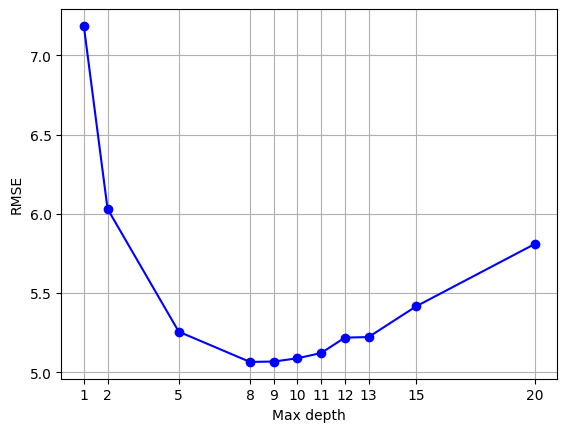

In [21]:
##### YOUR CODE STARTS #####
plt.plot(max_depths, depth_RMSEs, marker='o', linestyle='-', color='b')
plt.grid(True)
##### YOUR CODE ENDS #####
plt.xticks(max_depths)
plt.xlabel("Max depth")
plt.ylabel("RMSE")
plt.show()

According to the above figure, the most optimal decision tree depth is ...

<font color='red'> **(Homework exercise 4- b)** Based on above results train the `DecisionTreeRegressor` on the entire training data (use all the training datapoints, but still only the same features that were used in the task before). Use **the optimal tree depth** that you reported in **4 -a**. Predict the test set and submit the results to Kaggle. Check your results online and print out your new leaderboard score, which should be smaller than 4.02083. (0.5 points) </font>

In [22]:
##### YOUR CODE STARTS #####
optimal_depth = 8

dtr_final = DecisionTreeRegressor(max_depth=optimal_depth)
dtr_final.fit(X[['abs_diff_longitude', 'abs_diff_latitude']], y)

test_preds = dtr_final.predict(test[['abs_diff_longitude', 'abs_diff_latitude']])

submission = pd.DataFrame({'key': test['key'], 'fare_amount': test_preds})
submission.to_csv('dt_submission.csv', index=False)

!kaggle competitions submit -c new-york-city-taxi-fare-prediction -f dt_submission.csv -m "Decision Tree optimal depth"

# just copy paste your new score below:
my_score = 4.00653
print(f"My new score is {my_score}")
##### YOUR CODE ENDS #####

100% 454k/454k [00:01<00:00, 358kB/s]
Successfully submitted to New York City Taxi Fare PredictionMy new score is 3.95


# Bonus exercises
**NB, these are optional exercises! These will be graded more strictly, hence you really need to impress with high quality of the solution to earn points. Add elaborate explanations and cool visuals.**

## Bonus exercise 1 (2 bonus points):

<font color='red'> Visualising misclassified examples can help to debug the classification algorithm. But misclassified examples may have different probabilities. In this bonus exercise (optional) try modifying code we have written for the homework exercise 2 so that title now would include probability of a true class and of a wrong class. You would probably need to change the code of `classify_knn` function. Describe the results. </font>

## Bonus exercise 2 (up to 5 points): the grand challenge
<font color='red'> Try to get into top 300 places on public leaderboard (RMSE < 3.04) using different ML algorithms with different parameters, more features, more data, better preprocessing. Here are some ideas for improvement:
* Use more data (we only took 1M out of 2M, there are 53M more on the website)
* Do more preprocessing (remember negative prices or unrealistic numbers of passengers?)
* Use more/better features (e.g. euclidean distance, or google what is haversine distance)
* Use some other regression algorithm (e.g. look into RandomForestRegressor from sklearn.ensemble)
* Tune parameters of these algorithms
* Try something else!
</font>

<font color='red'>You should make a small post here with code and elaborate explanations of what you have tried (do it even you did not manage to break into top 300). **Report your final leaderboard rank**. Number of points would depend on quality of your explanations and the resulting rank.</font>


In [ ]:
# Hint:
R = 6378

def haversine_distance(lon1, lon2, lat1, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)

    All args must be of equal length.

    source: https://stackoverflow.com/a/29546836

    """
    # Convert latitude and longitude to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # Find the differences
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Apply the formula
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    # Calculate the angle (in radians)
    c = 2 * np.arcsin(np.sqrt(a))
    # Convert to kilometers
    km = R * c

    return km

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you spend on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

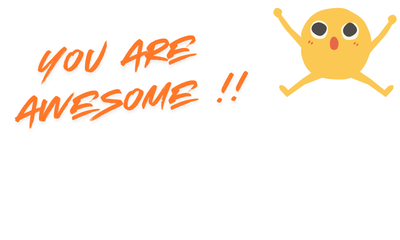

# <font color='red'>  End of the homework. Please don't delete this cell.</font>